In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/amulyas/penguin-size-dataset/penguins_size.csv")
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [2]:
print(df.isna().sum())
df["sex"].unique()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


array(['MALE', 'FEMALE', nan, '.'], dtype=object)

In [3]:
df_s = df.copy() # Ilk veri setini kaybetmemek için df_s dataframe_save değişkenini oluşturuyoruz

In [4]:
df_s.columns[2:]

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

In [5]:
from sklearn.preprocessing import OneHotEncoder

# kategorik deger olan cinsiyeti numeric yaptık imputation için
df_s['sex'] = df_s['sex'].map({'MALE': 0, 'FEMALE': 1}) # "." olan NaN olacak

In [6]:
df_s

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,0.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,1.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,1.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,1.0
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,1.0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,0.0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,1.0


In [7]:
print(df_s["sex"].value_counts())

sex
0.0    168
1.0    165
Name: count, dtype: int64


In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer # Null verileri basit bir ML modeli ile dolduracağız, veri seti küçük olduğu için maliyet sorunumuz yok.

imputer = IterativeImputer(max_iter=10, random_state=0)

cols_to_fix = df_s.columns[2:]
df_s[cols_to_fix] = pd.DataFrame(imputer.fit_transform(df_s[cols_to_fix]), columns=cols_to_fix)# fit_transform null değerleri ve sütun veri tipini otomatik tespit edebilir.
df_s["sex"] = df_s["sex"].astype(int).astype(float) # threshold 0.5
df_s

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,0.0
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,1.0
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,1.0
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,0.0
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,1.0
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,0.0
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,1.0
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,0.0
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,1.0


In [9]:
print(df_s.isna().sum())
print(df_s["sex"].value_counts())
print(df["sex"].value_counts())
print(df["species"].value_counts())
df_s

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
sex
0.0    178
1.0    166
Name: count, dtype: int64
sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,0.0
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,1.0
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,1.0
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,0.0
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,1.0
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,0.0
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,1.0
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,0.0
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,1.0


In [10]:
from sklearn.preprocessing import StandardScaler, LabelEncoder # encoding ve normalizasyn yapıcaz MLP için, çünkü nörün ağları sayısal değerlerle çalışıyor
from sklearn.model_selection import train_test_split
print(df["species"].unique(),df["island"].unique())

le = LabelEncoder()
df_s['species'] = le.fit_transform(df_s['species'])
df_s['island'] = le.fit_transform(df_s['island'])

['Adelie' 'Chinstrap' 'Gentoo'] ['Torgersen' 'Biscoe' 'Dream']


In [11]:
#species target sütunumuz o yüzden o hariç diğerleri StandartScaler ile normalizasyona girecekler.
y = df_s.iloc[:, 0].copy() # Sadece ilk sütun (Species)
X = df_s.iloc[:, 1:].copy() # İlk sütun hariç geri kalan her şey
col_to_norm = df_s.columns[1:]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.4, random_state=42, stratify=y)  # Veri az test büyük olmalı

In [12]:
# Split the existing training data into Training (80%) and Validation (20%)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train = X_train_final.copy()
y_train = y_train_final.copy()
del X_train_final, y_train_final

In [13]:
def one_hot_encode(Y, num_classes=3):
    Y_arr = np.array(Y).reshape(-1)
    m = Y_arr.shape[0]
    one_hot = np.zeros((num_classes, m))
    one_hot[Y_arr.astype(int), np.arange(m)] = 1
    return one_hot
y_train = one_hot_encode(y_train)
y_val = one_hot_encode(y_val)
y_test = one_hot_encode(y_test)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train = X_train_scaled
X_test = X_test_scaled 
del X_train_scaled, X_test_scaled

<h1>Veri temizliği burada bitiyor. Şimdi ise MLP Sınıfını oluşturma ve sonrası aşamasına geçiyoruz.</h1>

In [15]:
def initialize_parameters(n_x, n_h, n_y = 1):
    np.random.seed(42) # SEED BURADA
    W1 = np.random.randn(n_h, n_x) * np.sqrt(2 / n_x) #He initilaziton for ReLU
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * np.sqrt(2 / n_h)
    b2 = np.zeros((n_y, 1))
    
    parameters = {
        "W1" : W1,
        "b1" : b1,
        "W2" : W2,
        "b2" : b2
    }
    return parameters

test_parameters = initialize_parameters(X.shape[1], 5, 3) # 3 sınıf var

print("W1 = " + str(test_parameters["W1"].shape))
print("b1 = " + str(test_parameters["b1"].shape))
print("W2 = " + str(test_parameters["W2"].shape))
print("b2 = " + str(test_parameters["b2"].shape))
print("X_train = " + str(X_train.shape))

W1 = (5, 6)
b1 = (5, 1)
W2 = (3, 5)
b2 = (3, 1)
X_train = (164, 6)


In [16]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True)) #Çoklu sınıflandırma olduğu için softmax katmanı ekliyoruz argmaxla sınıflandırma yapacağız
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def sigmoid(Z):
    return 1 / (1 + np.exp(-1 * Z))

def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    Z1 = np.dot(W1, X.T) + b1
    A1 = np.maximum(0, Z1) #reLU
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    
    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }
    
    return A2, cache


In [17]:
test_A2, test_cache = forward_propagation(X_train, test_parameters)
test_A2

array([[0.27597233, 0.54392533, 0.79020895, 0.51078038, 0.6059455 ,
        0.60112224, 0.23955944, 0.61222116, 0.49832565, 0.74399692,
        0.51735672, 0.43431834, 0.53433153, 0.44912327, 0.52405856,
        0.40902071, 0.5764719 , 0.41999732, 0.6225619 , 0.60141999,
        0.5059107 , 0.58536328, 0.21632649, 0.18895907, 0.87474832,
        0.63017755, 0.4888511 , 0.277494  , 0.43182175, 0.54691935,
        0.75751947, 0.79107921, 0.34420035, 0.48153599, 0.76784895,
        0.68859068, 0.19555243, 0.50262471, 0.46761857, 0.53899263,
        0.63784858, 0.16268722, 0.57053462, 0.57024396, 0.60811804,
        0.73564971, 0.52994746, 0.73668908, 0.48454388, 0.25838134,
        0.6459132 , 0.19286097, 0.17053493, 0.63308664, 0.49917366,
        0.4758188 , 0.79032696, 0.43103215, 0.55792234, 0.69299036,
        0.49571141, 0.76590337, 0.72302021, 0.56478457, 0.49033166,
        0.49944624, 0.56388978, 0.77061033, 0.68575259, 0.46044793,
        0.47388137, 0.50135933, 0.14406066, 0.23

In [18]:
def compute_cost(A2, Y_one_hot):
    m = Y_one_hot.shape[1]
    epsilon = 1e-15
    cost = -np.sum(Y_one_hot * np.log(A2 + epsilon)) / m
    return float(np.squeeze(cost))

In [19]:
test_cost = compute_cost(test_A2, y_train)
test_cost

1.4369718445982866

In [20]:
def backpropagation(X, Y_one_hot, cache, parameters):
    m = X.shape[0]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    Z1 = cache["Z1"]
    
    dZ2 = A2 - Y_one_hot
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = np.array(dA1, copy=True)
    dZ1[Z1 <= 0] = 0
    
    dW1 = (1 / m) * np.dot(dZ1, X)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

In [21]:
test_grads = backpropagation(X_train, y_train, test_cache, test_parameters)
test_grads

{'dW1': array([[ 0.22635893, -0.07737739,  0.29116466, -0.24662787, -0.28002628,
          0.03044942],
        [-0.11428559,  0.2353771 , -0.02359829,  0.14531751,  0.1046568 ,
         -0.09313549],
        [ 0.03919657,  0.01657764,  0.01836599, -0.03229906, -0.0418384 ,
          0.03828221],
        [ 0.03430224, -0.03859598,  0.12372614, -0.08750365, -0.07505184,
         -0.03657388],
        [-0.30527633,  0.28617265, -0.45257986,  0.48297245,  0.44937715,
         -0.00605716]]),
 'db1': array([[-0.01660195],
        [ 0.11878728],
        [ 0.01313197],
        [ 0.10360461],
        [ 0.33721844]]),
 'dW2': array([[ 0.06812125,  0.0488463 , -0.14544275, -0.31307496,  0.2003324 ],
        [-0.04404953, -0.12146701, -0.0172911 , -0.01067844,  0.06929455],
        [-0.02407172,  0.07262072,  0.16273385,  0.32375339, -0.26962695]]),
 'db2': array([[ 0.07183471],
        [-0.06828294],
        [-0.00355177]])}

In [22]:
def update_parameters(parameters, grads, learning_rate = 0.01):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    paramaters = {
        "W1" : W1,
        "b1" : b1,
        "W2" : W2,
        "b2" : b2
    }
    
    return parameters

In [23]:
test_learned_parameters = update_parameters(test_parameters, test_grads)
test_learned_parameters

{'W1': array([[ 0.28451446, -0.07905316,  0.37103151,  0.88178798, -0.13238825,
         -0.13548353],
        [ 0.9129018 ,  0.44072488, -0.27081518,  0.31179401, -0.2686009 ,
         -0.26795784],
        [ 0.13930502, -1.10479864, -0.99606543, -0.32431387, -0.58433994,
          0.18104796],
        [-0.52459097, -0.81500796,  0.84495545, -0.12947697,  0.03973795,
         -0.82221301],
        [-0.31124675,  0.06117946, -0.66000065,  0.21207963, -0.35127268,
         -0.16834889]]),
 'b1': array([[ 0.00016602],
        [-0.00118787],
        [-0.00013132],
        [-0.00103605],
        [-0.00337218]]),
 'W2': array([[-0.38123389,  1.17099512, -0.00708197, -0.66582438,  0.51821976],
        [-0.77168882,  0.13331161, -1.2392313 , -0.83991183,  0.12381303],
        [ 0.46728799,  0.10765661, -0.07476973, -0.19367223, -0.93240314]]),
 'b2': array([[-7.18347137e-04],
        [ 6.82829397e-04],
        [ 3.55177400e-05]])}

In [24]:
def nn_model(X, Y, n_x, n_h, n_y, n_steps = 100, print_cost = True):
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    for i in range(0, n_steps):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backpropagation(X, Y, cache, parameters)
        parameters = update_parameters(parameters, grads)
        
        if print_cost and i % 10 == 0:
            print("cost %i %f" %(i,cost))
    
    return parameters

In [25]:
parameters = nn_model(X_train, y_train, X_train.shape[1], n_h = 6, n_y = 3, n_steps = 500) # Layer sayıları burada

cost 0 1.347597
cost 10 1.231702
cost 20 1.138116
cost 30 1.061441
cost 40 0.996997
cost 50 0.942393
cost 60 0.895627
cost 70 0.854396
cost 80 0.817457
cost 90 0.783352
cost 100 0.752647
cost 110 0.724474
cost 120 0.698132
cost 130 0.673145
cost 140 0.649290
cost 150 0.626953
cost 160 0.605665
cost 170 0.585387
cost 180 0.565819
cost 190 0.547297
cost 200 0.529680
cost 210 0.512650
cost 220 0.496244
cost 230 0.479671
cost 240 0.463619
cost 250 0.448128
cost 260 0.433351
cost 270 0.419341
cost 280 0.405680
cost 290 0.392566
cost 300 0.380112
cost 310 0.368140
cost 320 0.356579
cost 330 0.345381
cost 340 0.334425
cost 350 0.323882
cost 360 0.313888
cost 370 0.304388
cost 380 0.295102
cost 390 0.286234
cost 400 0.277819
cost 410 0.269824
cost 420 0.262175
cost 430 0.254933
cost 440 0.248117
cost 450 0.241668
cost 460 0.235555
cost 470 0.229739
cost 480 0.224187
cost 490 0.218914


In [26]:
def predict(parameters, X):
    A2, cache = forward_propagation(X, parameters)
    predicts = np.argmax(A2, axis=0)
    return predicts

In [27]:
predicts = predict(parameters, X_test)
predicts

array([2, 0, 1, 2, 0, 1, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 1, 1, 2, 0, 0,
       0, 2, 0, 1, 1, 0, 1, 2, 2, 1, 1, 0, 1, 0, 0, 2, 2, 0, 0, 0, 2, 0,
       0, 1, 1, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 0, 0, 0, 0, 2, 2, 0, 2,
       0, 0, 2, 1, 2, 0, 0, 0, 1, 1, 2, 0, 2, 0, 0, 2, 2, 0, 1, 2, 0, 2,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 0, 2, 2, 0, 0, 0, 2, 1, 2, 1, 2, 0,
       0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 1, 0, 0, 2, 2, 2, 1, 0, 2, 2, 0,
       2, 1, 2, 0, 2, 2])

In [28]:
y_true = np.argmax(y_test, axis=0)
accuracy = np.mean(y_true == predicts)
print("accuracy:", accuracy)

#sınıf dengesizliği olduğu için F1 skora bakalım
from sklearn.metrics import f1_score
f1_macro = f1_score(y_true, predicts, average='macro')
print("f1 skoru:", f1_macro)

accuracy: 0.9637681159420289
f1 skoru: 0.9583915031069502


In [29]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
def evaluate_model(y_true, y_pred, class_names=['Adelie', 'Chinstrap', 'Gentoo']):
    # Görselleştirme (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.show()

    # Raporu sözlük olarak al (Metrikleri çekebilmek için)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Sadece Macro F1 skorunu döndürelim
    return report['macro avg']['f1-score']

In [30]:
def nn_model(X, Y, X_val, Y_val, n_x, n_h, n_y, n_steps=100, learning_rate=0.01, print_cost= True): # fonksiyonu değiştiriyorum "overwrite"
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    # Lists to store loss history
    train_costs = []
    val_costs = []
    
    for i in range(0, n_steps):
        # Forward propagation (Training)
        A2, cache = forward_propagation(X, parameters)
        train_cost = compute_cost(A2, Y)
        
        # Forward propagation (Validation) - No backprop here!
        A2_val, _ = forward_propagation(X_val, parameters)
        val_cost = compute_cost(A2_val, Y_val)
        
        # Backpropagation and Update
        grads = backpropagation(X, Y, cache, parameters)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Save costs
        train_costs.append(train_cost)
        val_costs.append(val_cost)
        
        if print_cost and i % 50 == 0:
            print(f"Iteration {i}: Train Cost = {train_cost:.6f} | Val Cost = {val_cost:.6f}")
    
    return parameters, train_costs, val_costs

# Run the updated model
parameters, train_costs, val_costs = nn_model(
    X_train, y_train, X_val, y_val, 
    n_x=X_train.shape[1], n_h=6, n_y=3, n_steps=1000
)

Iteration 0: Train Cost = 1.347597 | Val Cost = 1.169604
Iteration 50: Train Cost = 0.942393 | Val Cost = 0.869296
Iteration 100: Train Cost = 0.752647 | Val Cost = 0.717423
Iteration 150: Train Cost = 0.626953 | Val Cost = 0.609206
Iteration 200: Train Cost = 0.529680 | Val Cost = 0.516684
Iteration 250: Train Cost = 0.448128 | Val Cost = 0.435905
Iteration 300: Train Cost = 0.380112 | Val Cost = 0.365679
Iteration 350: Train Cost = 0.323882 | Val Cost = 0.306724
Iteration 400: Train Cost = 0.277819 | Val Cost = 0.256097
Iteration 450: Train Cost = 0.241668 | Val Cost = 0.215352
Iteration 500: Train Cost = 0.213907 | Val Cost = 0.183799
Iteration 550: Train Cost = 0.192099 | Val Cost = 0.159201
Iteration 600: Train Cost = 0.174579 | Val Cost = 0.139691
Iteration 650: Train Cost = 0.160222 | Val Cost = 0.123930
Iteration 700: Train Cost = 0.148197 | Val Cost = 0.110946
Iteration 750: Train Cost = 0.138060 | Val Cost = 0.100182
Iteration 800: Train Cost = 0.129393 | Val Cost = 0.091136


In [31]:
def nn_model_sgd(X, Y, X_val, Y_val, n_x, n_h, n_y, n_steps=501, learning_rate=0.01, print_cost=True):
    # Parametreleri başlat
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    train_costs = []
    val_costs = []
    m = X.shape[0]

    for i in range(n_steps):
        # Veriyi her epoch başında karıştır (Shuffling)
        # Bu, modelin verinin sırasını ezberlemesini önler
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        Y_shuffled = Y[:, permutation]
        
        epoch_cost = 0
        
        for j in range(m):
            # Tek bir örnek seç (Stochastic adımı)
            # xi: (1, n_x), yi: (n_y, 1)
            xi = X_shuffled[j:j+1]
            yi = Y_shuffled[:, j:j+1]
            
            # İleri Yayılım (Sadece bu örnek için)
            ai, cache_i = forward_propagation(xi, parameters)
            
            # Maliyet hesapla ve toplama ekle
            sample_cost = compute_cost(ai, yi)
            epoch_cost += sample_cost
            
            # 5. Geri Yayılım ve Güncelleme (Her örnekten sonra ağırlıklar güncellenir)
            grads = backpropagation(xi, yi, cache_i, parameters)
            parameters = update_parameters(parameters, grads, learning_rate)
        
        # Epoch sonunda ortalama maliyeti kaydet
        avg_train_cost = epoch_cost / m
        train_costs.append(avg_train_cost)
        
        # Validasyon maliyetini tüm set üzerinden hesapla (Genelleme kontrolü)
        A2_val, _ = forward_propagation(X_val, parameters)
        val_cost = compute_cost(A2_val, Y_val)
        val_costs.append(val_cost)

        if print_cost and i % 50 == 0:
            print(f"Epoch {i}: Train Cost = {avg_train_cost:.6f} | Val Cost = {val_cost:.6f}")
            
    return parameters, train_costs, val_costs

# Ekstra: valdiasyon/train loss grafiği ile overfitting/underfitting var mı diye kontrol edelim

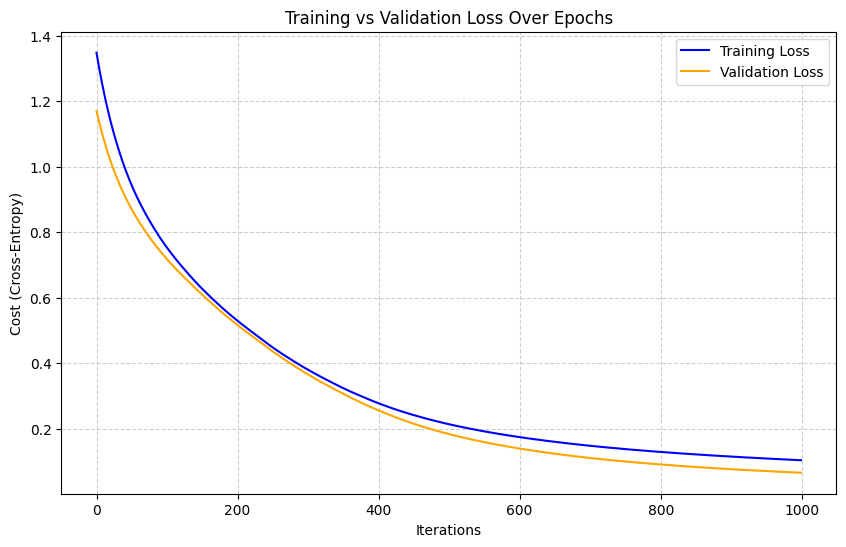

In [32]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_costs, val_costs):
    plt.figure(figsize=(10, 6))
    plt.plot(train_costs, label='Training Loss', color='blue')
    plt.plot(val_costs, label='Validation Loss', color='orange')
    plt.title('Training vs Validation Loss Over Epochs')
    plt.xlabel('Iterations')
    plt.ylabel('Cost (Cross-Entropy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_learning_curves(train_costs, val_costs)

Çok uyumlu geldiler ve bu durum modelin çok başarılı olduğunu herhangi bir yanlılık, öğrenememe göstermediğini gösteriyor. Model, veriye "fit" olmuş diyebiliriz: Grafik, herhangi bir "U" dönüşü göstermemiş, ve iki çizgi üst üste değil yani bir genellemenin olduğu da söylenebilir.

# Buradan sonra Sklearn ile olabildiğince otomatik şekilde testlerimizi yapalım.
# Fakat proje dosyasına göre bu ister hem baştan yazılmış hem de sklearn MLP'sini kapsayacağından ikisi için de kapsamlı bir fonksiyon yazalım ve deneylerimizi 1 satırda yazmaya çalışalım.

In [33]:
# Global sonuç logu listesi
experiment_log = []

def log_experiment(exp_name, n_h, n_steps, l_r, optimizer, f1_macro):
    #Deney verilerini merkezi listeye ekliyor
    entry = {
        "Experiment": exp_name,
        "n_h": n_h,
        "n_steps": n_steps,
        "l_r": l_r,
        "Optimizer": optimizer,
        "F1_Macro": round(f1_macro, 4)
    }
    experiment_log.append(entry)
    print(f"{exp_name} sozluge kaydedildi. F1: {round(f1_macro, 4)}")

In [34]:
def run_MLP (X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=500, learning_rate=0.01, print_cost=True, exp_name=None):
    n_x = X_train.shape[1] 
    n_y = 3
    parameters, train_costs, val_costs = nn_model(
        X_train, y_train, X_val, y_val, 
        n_x=n_x, n_h=n_h, n_y=n_y, 
        n_steps=n_steps, learning_rate=learning_rate, print_cost=print_cost
    )
    plot_learning_curves(train_costs, val_costs)
    predicts = predict(parameters, X_test)
    y_true = np.argmax(y_test, axis=0)
    f1_macro = evaluate_model(y_true, predicts)
    
    #Sonuçları dictionary günlüğüne kaydet
    log_experiment(exp_name, n_h, n_steps, learning_rate, "BGD", f1_macro)
    # Ağırlıkları ve biasları döndürüyoruz None yerine, işimize yarayabilir.
    return parameters

In [35]:
def run_MLP_sgd(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=500, learning_rate=0.01, print_cost=True, exp_name=None):
    n_x = X_train.shape[1]
    n_y = 3
    parameters, train_costs, val_costs = nn_model_sgd(
        X_train, y_train, X_val, y_val, 
        n_x=n_x, n_h=n_h, n_y=n_y, 
        n_steps=n_steps, learning_rate=learning_rate, print_cost=print_cost
    )
    plot_learning_curves(train_costs, val_costs)
    predicts = predict(parameters, X_test)
    y_true = np.argmax(y_test, axis=0)
    f1_macro = evaluate_model(y_true, predicts)
    
    #Sonuçları dictionary günlüğüne kaydet
    log_experiment(exp_name, n_h, n_steps, learning_rate, "SGD", f1_macro)
    # Ağırlıkları ve biasları döndürüyoruz None yerine, işimize yarayabilir.
    return parameters

Iteration 0: Train Cost = 1.347597 | Val Cost = 1.169604
Iteration 50: Train Cost = 0.942393 | Val Cost = 0.869296
Iteration 100: Train Cost = 0.752647 | Val Cost = 0.717423
Iteration 150: Train Cost = 0.626953 | Val Cost = 0.609206
Iteration 200: Train Cost = 0.529680 | Val Cost = 0.516684
Iteration 250: Train Cost = 0.448128 | Val Cost = 0.435905
Iteration 300: Train Cost = 0.380112 | Val Cost = 0.365679
Iteration 350: Train Cost = 0.323882 | Val Cost = 0.306724
Iteration 400: Train Cost = 0.277819 | Val Cost = 0.256097
Iteration 450: Train Cost = 0.241668 | Val Cost = 0.215352
Iteration 500: Train Cost = 0.213907 | Val Cost = 0.183799


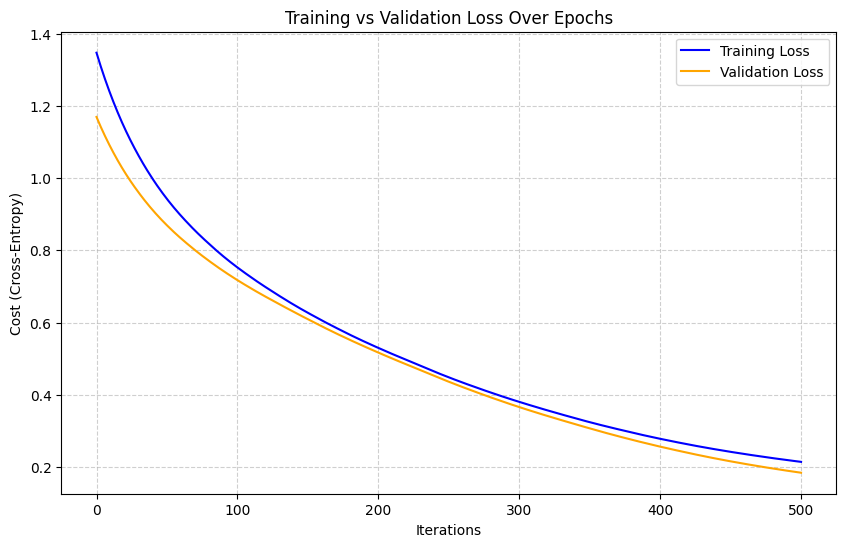

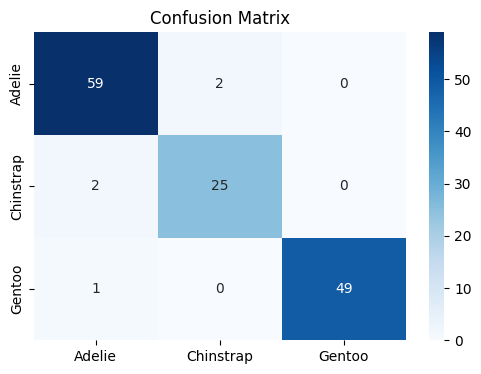

exp1_1 sozluge kaydedildi. F1: 0.9584


In [36]:
exp1_1= run_MLP(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=501, learning_rate=0.01, print_cost=True,exp_name="exp1_1")

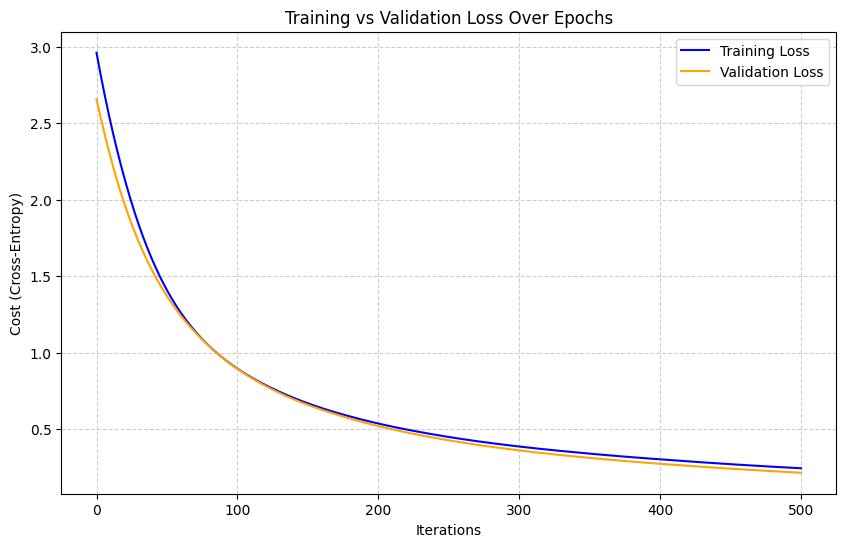

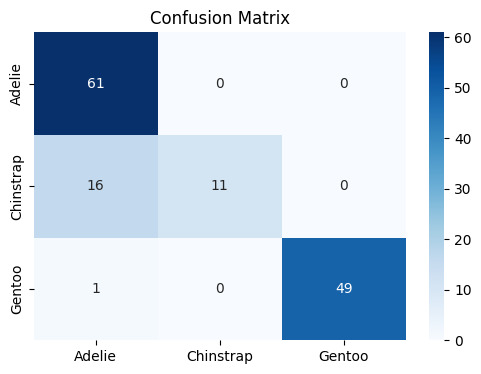

exp1_2 sozluge kaydedildi. F1: 0.8155


In [37]:
# Hidden layer sayısını 9 yapalım ve test edelim, artık cost yazdırmıyoruz
exp1_2= run_MLP(X_train, X_val, X_test, y_train, y_val, y_test, n_h=9, n_steps=501, learning_rate=0.01, print_cost=False,exp_name="exp1_2") # Overfit arttı f1 skor düştü
# sınıf dengesizliği derinleşti


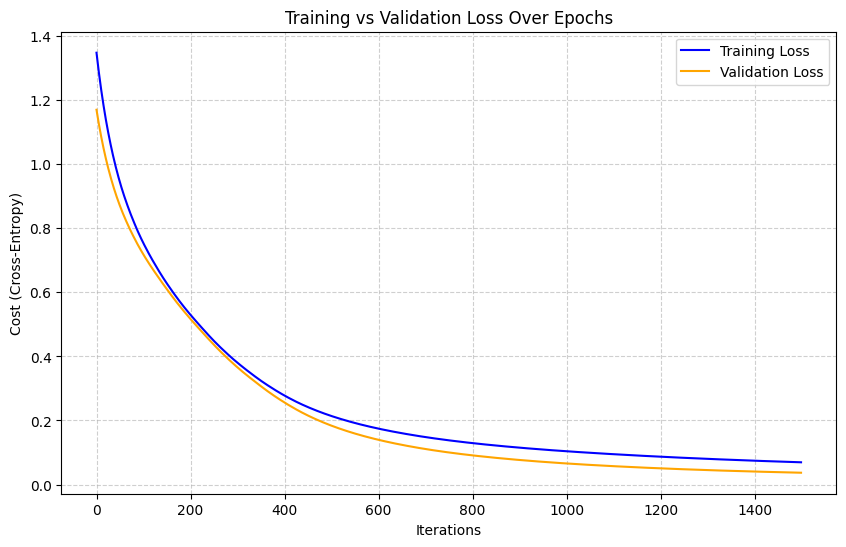

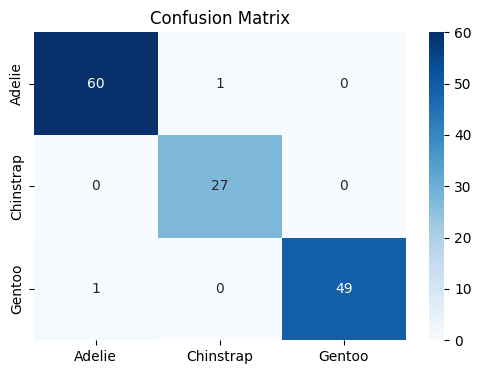

exp1_3 sozluge kaydedildi. F1: 0.9851


In [38]:
# n_steps sayısını 1500 yapalım ve test edelim, diğerleri varsayılan değerlerde
exp1_3= run_MLP(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=1500, learning_rate=0.01, print_cost=False, exp_name="exp1_3") # çok iyi performans, genelleme korundu

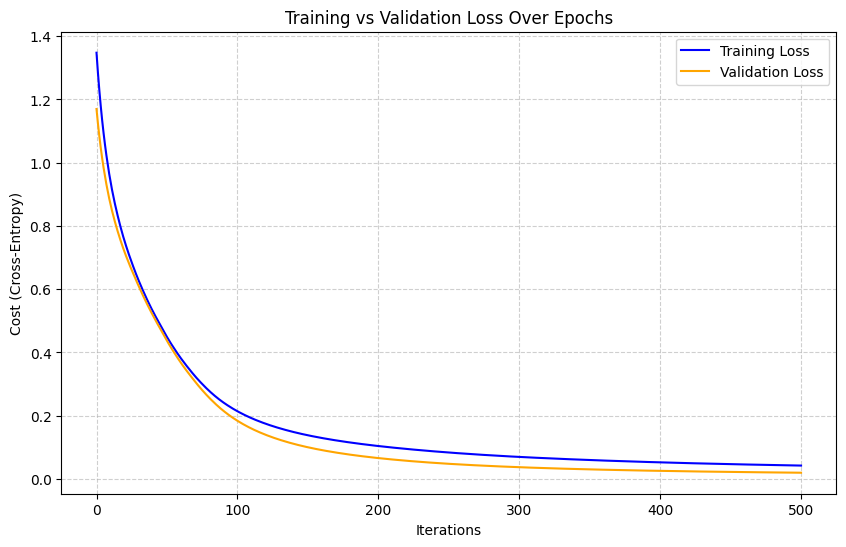

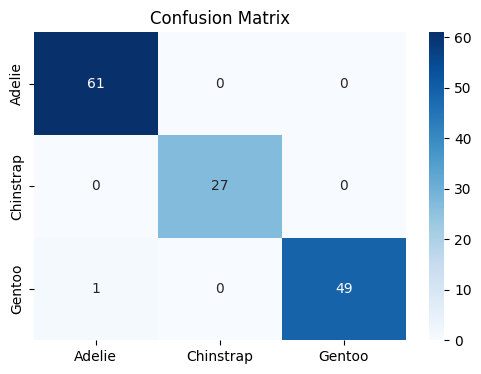

exp1_4 sozluge kaydedildi. F1: 0.9939


In [39]:
# learning_rate 0.05 olsun
exp1_4= run_MLP(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=501, learning_rate=0.05, print_cost=False,exp_name= "exp1_4") # çok iyi performans
#fakat overfit sinyalleri alıyoruz 0-100 iterasyonları arasında

Epoch 0: Train Cost = 0.880698 | Val Cost = 0.583285
Epoch 50: Train Cost = 0.016255 | Val Cost = 0.006094
Epoch 100: Train Cost = 0.008686 | Val Cost = 0.003535
Epoch 150: Train Cost = 0.005686 | Val Cost = 0.002137
Epoch 200: Train Cost = 0.004086 | Val Cost = 0.001356
Epoch 250: Train Cost = 0.003107 | Val Cost = 0.001088
Epoch 300: Train Cost = 0.002471 | Val Cost = 0.000776
Epoch 350: Train Cost = 0.002030 | Val Cost = 0.000647
Epoch 400: Train Cost = 0.001699 | Val Cost = 0.000556
Epoch 450: Train Cost = 0.001453 | Val Cost = 0.000456
Epoch 500: Train Cost = 0.001274 | Val Cost = 0.000408


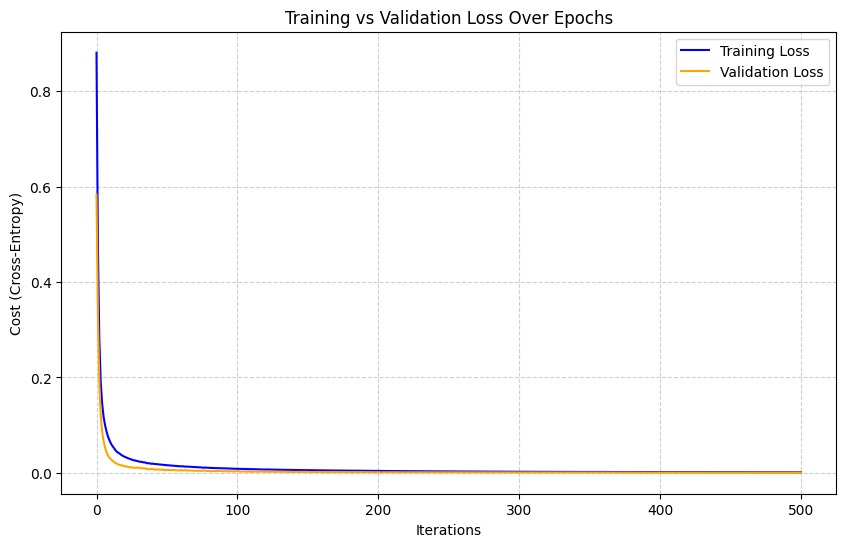

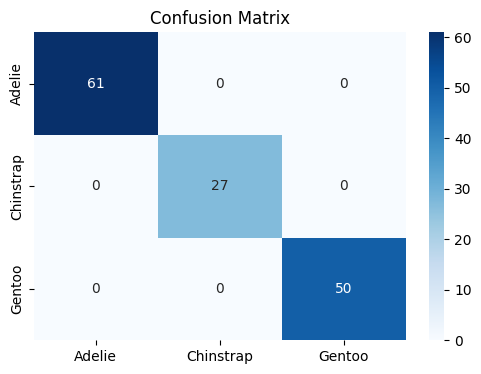

exp2_1 sozluge kaydedildi. F1: 1.0


In [40]:
# Deney 2 (experiment 2)'nin deney 1'den farkı "batch gradient descent" yerine "stochastic gradient descent" SGD kullanıyor olmasıdır.
exp2_1 = run_MLP_sgd(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=501, learning_rate=0.01, print_cost=True,exp_name= "exp2_1") # Super overfit
#SGD ÇOK HIZLI YAKINSIYOR n_steps düşürülmeli

Epoch 0: Train Cost = 0.880698 | Val Cost = 0.583285


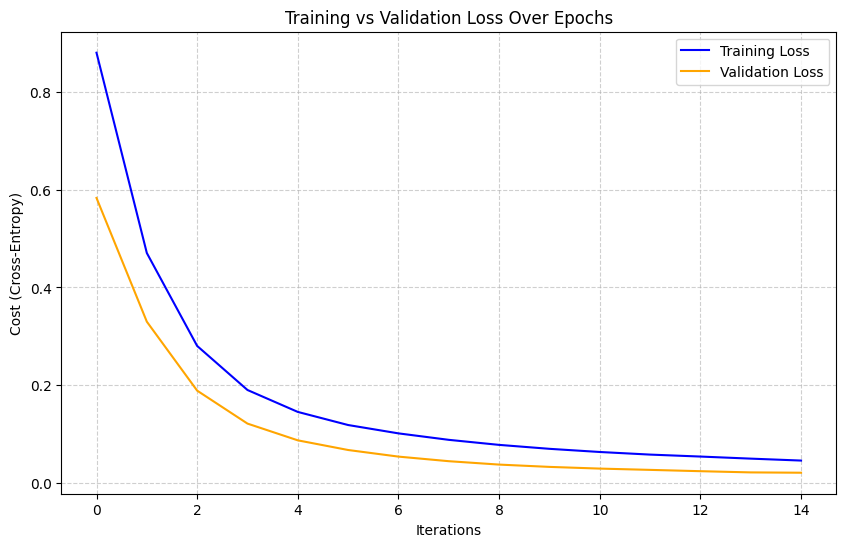

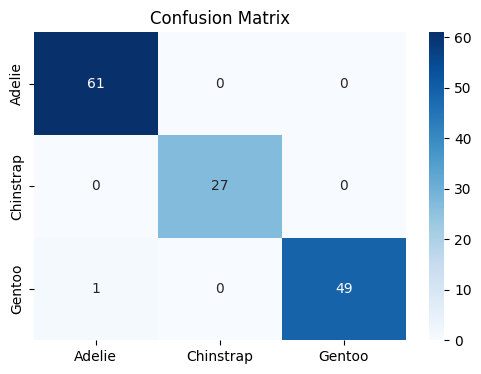

exp2_2 sozluge kaydedildi. F1: 0.9939


In [41]:
# yukarıdaki sonuçtan sonra n_steps = 15 yapalım
exp2_2 = run_MLP_sgd(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=15, learning_rate=0.01, print_cost=True,exp_name= "exp2_2")
# Super sonuç genelleme okey

Epoch 0: Train Cost = 1.153824 | Val Cost = 0.907069


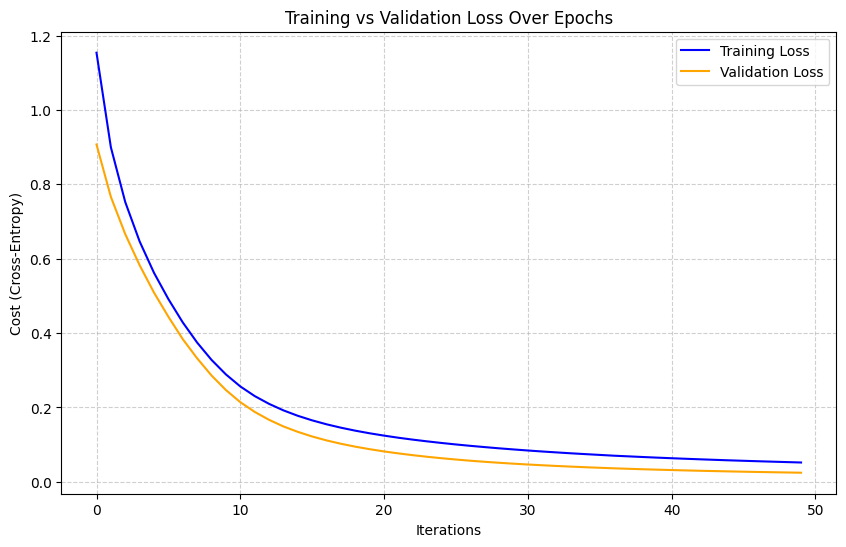

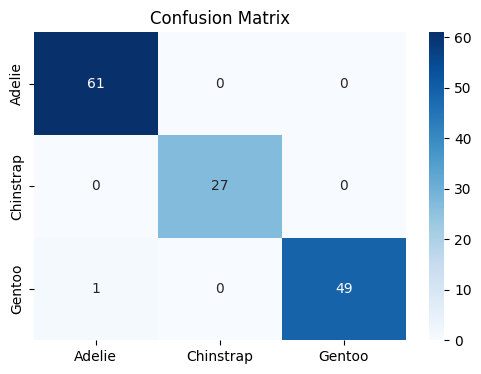

exp2_3 sozluge kaydedildi. F1: 0.9939


In [42]:
# learning_rate'i 4 kat düşürelim, n_steps = 50
exp2_3 = run_MLP_sgd(X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=50, learning_rate=0.0025, print_cost=True,exp_name= "exp2_3")
# Güzel sonuç grafik biraz overfite yakınlaşan türden geldi

Epoch 0: Train Cost = 2.188617 | Val Cost = 1.503687


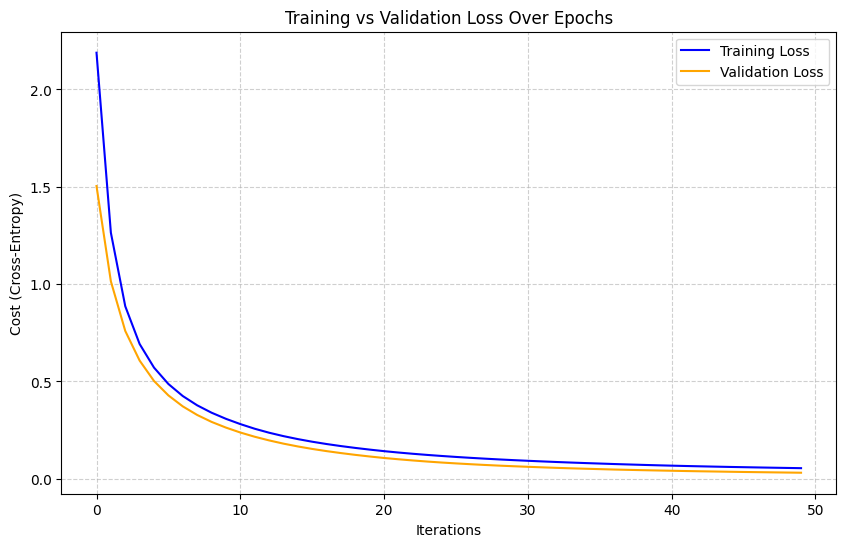

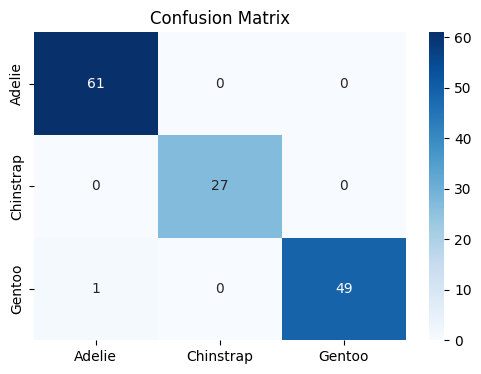

exp2_4 sozluge kaydedildi. F1: 0.9939


In [43]:
# n_steps = 50, lr = 0.0025 ve hidden layer = 9 olsun
exp2_4 = run_MLP_sgd(X_train, X_val, X_test, y_train, y_val, y_test, n_h=9, n_steps=50, learning_rate=0.0025, print_cost=True,exp_name= "exp2_4")
# Nöron sayısı arttı ve overfite sebep oldu.

# Raporun bu kısmına kadar tamamladık, şimdi daha modern yöntemler içeren nihai bir model oluşturacağız.

In [44]:
from sklearn.neural_network import MLPClassifier
# Optimizer : Adaptive Moment Estimation, Regularization : L2 ve erken durdurma yöntemlerini sklearn üzerinden alarak kullandı. Bakalım sonuçlar nasıl gelecek.
def run_MLP_sklearn(exp_name, X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=1000, l_r=0.001, alpha=0.001):
    # alpha: L2 regularization parametresi
    # early_stopping: True yapıldığında otomatik olarak validation set ayırır ve durur
    mlp = MLPClassifier(
        hidden_layer_sizes=(n_h,),
        activation='relu',
        solver='adam',
        alpha=alpha,           # L2 Regularization
        learning_rate_init=l_r,
        max_iter=n_steps,
        early_stopping=True,   # Early Stopping Aktif
        validation_fraction=0.1, # Doğrulama oranı
        n_iter_no_change=20,   # Patience (Sabır) süresi
        random_state=42
    )

    #Modeli Eğit (Y'yi one-hot değil, 1D etiket olarak ister)
    y_train_labels = np.argmax(y_train, axis=0)
    mlp.fit(X_train, y_train_labels)
    
    # --- Grafik ---
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Mavi Çizgi: Training Loss (Eğitim Kaybı)
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("Train Cost (Loss)", color="tab:blue")
    ax1.plot(mlp.loss_curve_, color="tab:blue", label="Train Loss", linewidth=2)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Kırmızı Çizgi: Validation Error (Doğrulama Hatası = 1 - Accuracy)
    ax2 = ax1.twinx()  
    ax2.set_ylabel("Validation Error", color="tab:red")  
    val_error = [1 - score for score in mlp.validation_scores_]
    ax2.plot(val_error, color="tab:red", label="Validation Error", linewidth=2, linestyle="--")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title(f"Overfitting/Underfitting Analizi - {exp_name}")
    fig.tight_layout()
    plt.show()
    # -------------------------------------------------------------------------

    predicts = mlp.predict(X_test)
    y_test_labels = np.argmax(y_test, axis=0)
    
    # evaluate_model fonksiyonunu kullanıyoruz
    f1 = evaluate_model(y_test_labels, predicts)
    
    log_experiment(exp_name, n_h, mlp.n_iter_, l_r, "Sklearn-Adam+L2+EarlyStop", f1)
    
    return mlp

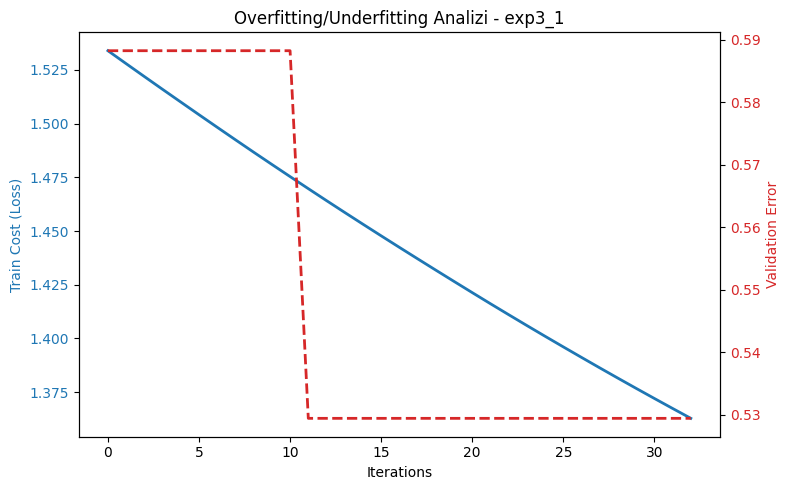

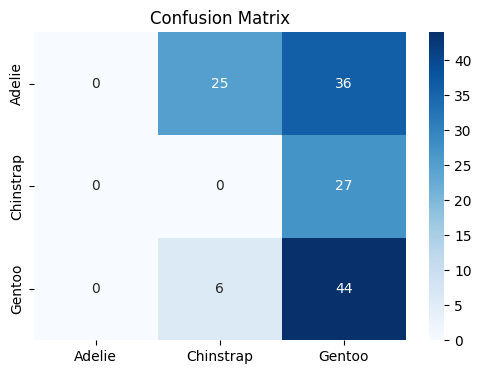

exp3_1 sozluge kaydedildi. F1: 0.1868


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
exp3_1 = run_MLP_sklearn("exp3_1", X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=1000, l_r=0.001, alpha=0.1) 
#alpha çok yüksek olabilir, ya da l_2 çok düşük ve bu da early stoppingin direkt açılmasına sebep oluyor.

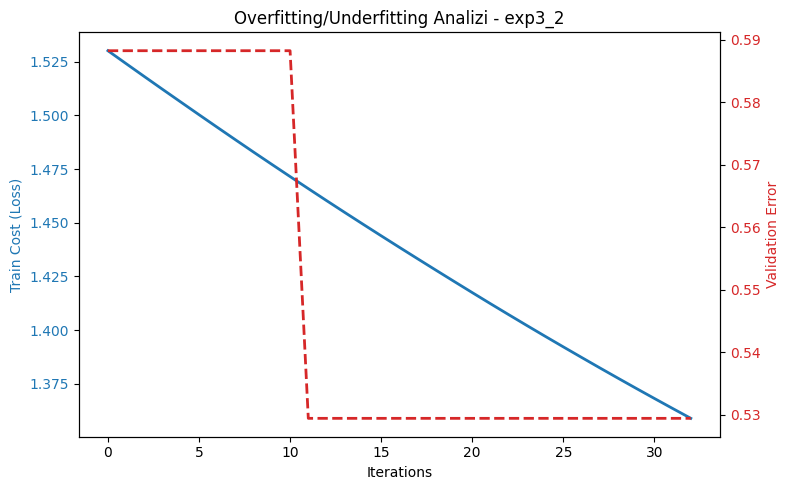

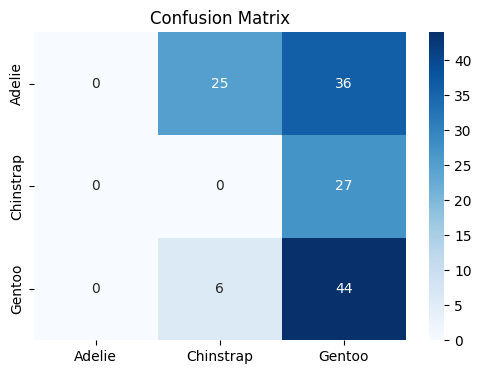

exp3_2 sozluge kaydedildi. F1: 0.1868


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [46]:
# L2 için alpha katsayısını 100 kat düşürelim
exp3_2 = run_MLP_sklearn("exp3_2", X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=1000, l_r=0.001, alpha=0.001) 
#Model hala veriyi anlamlandıramıyor, gizli katman sayısını artıralım

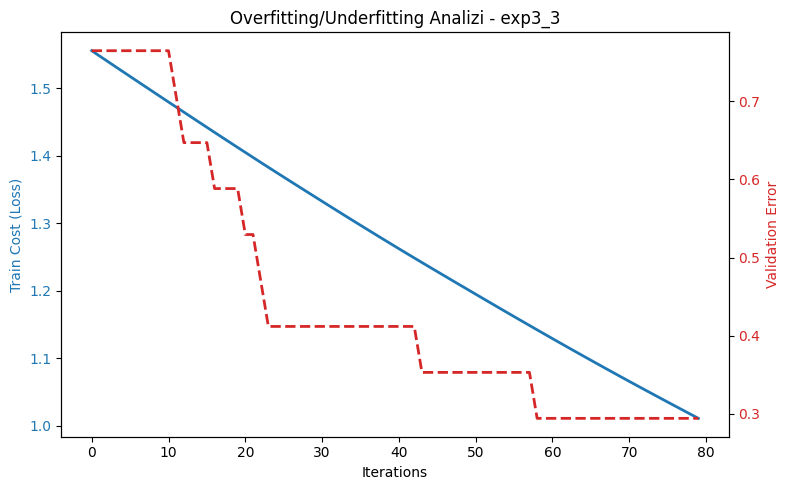

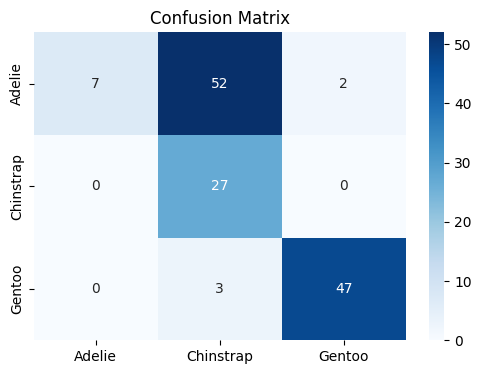

exp3_3 sozluge kaydedildi. F1: 0.5503


In [47]:
# gizli katmandaki nöron sayısı 6'dan 9'a çıkartıldı
exp3_3 = run_MLP_sklearn("exp3_3", X_train, X_val, X_test, y_train, y_val, y_test, n_h=9, n_steps=1000, l_r=0.001, alpha=0.1) 
# evet modelde iyileşme görülüyor ama ana sorun l_r düşüklüğü olmalı

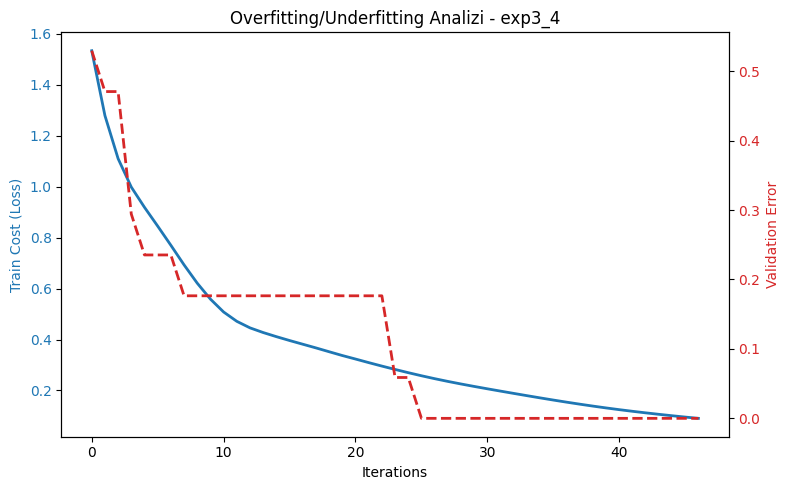

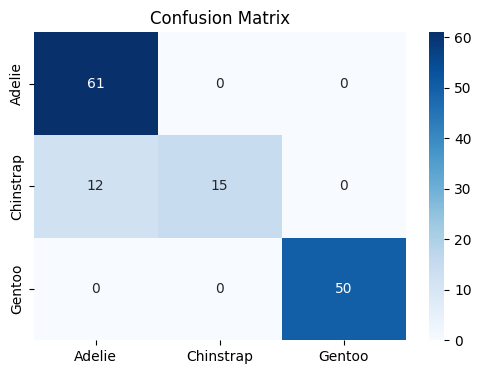

exp3_4 sozluge kaydedildi. F1: 0.8749


In [48]:
#learning_rate 50 kat artırıldı, diğer parametreler default olacak şekilde, şimdi en iyilerini deneyelim
exp3_4 = run_MLP_sklearn("exp3_4", X_train, X_val, X_test, y_train, y_val, y_test, n_h=6, n_steps=1000, l_r=0.05, alpha=0.1) 

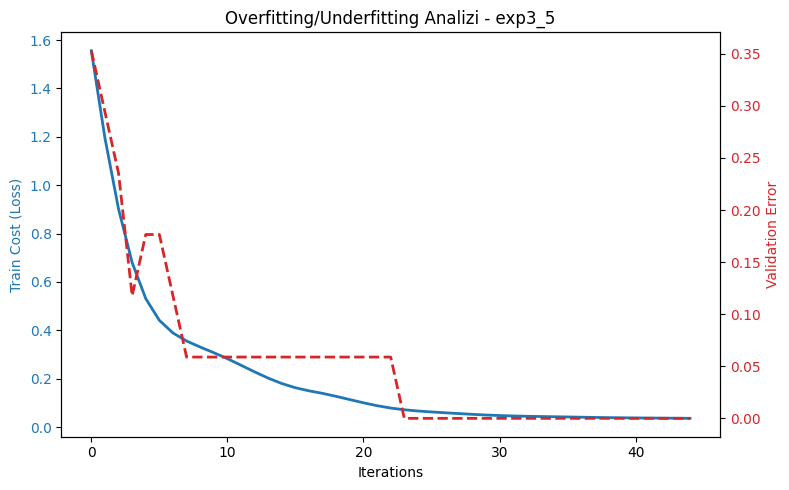

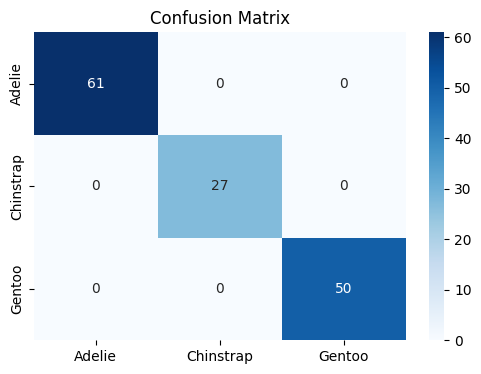

exp3_5 sozluge kaydedildi. F1: 1.0


In [49]:
# n_h = 9, lr= 0.05, alpha regularization = 0.001
exp3_5 = run_MLP_sklearn("exp3_5", X_train, X_val, X_test, y_train, y_val, y_test, n_h=9, n_steps=1000, l_r=0.05, alpha=0.1) 
# model çok iyi biliyor ve 46.iterasyonda max performansa ulaştı, 
# veri eksikliği olduğu için gerçek performansını maalesef ki test edemiyoruz, test size = 0.4 mevcut durumda. 
# NOT: alpha katsayısını 0.1 yaptığımda da yine çok benzer sonuç alınmıştır.

In [50]:
df_results = pd.DataFrame(experiment_log)
display(df_results.sort_values(by="F1_Macro", ascending=False))

,Experiment,n_h,n_steps,l_r,Optimizer,F1_Macro
4,exp2_1,6,501,0.0100,SGD,1.0000
12,exp3_5,9,45,0.0500,Sklearn-Adam+L2+EarlyStop,1.0000
3,exp1_4,6,501,0.0500,BGD,0.9939
5,exp2_2,6,15,0.0100,SGD,0.9939
7,exp2_4,9,50,0.0025,SGD,0.9939
6,exp2_3,6,50,0.0025,SGD,0.9939
2,exp1_3,6,1500,0.0100,BGD,0.9851
0,exp1_1,6,501,0.0100,BGD,0.9584
11,exp3_4,6,47,0.0500,Sklearn-Adam+L2+EarlyStop,0.8749
1,exp1_2,9,501,0.0100,BGD,0.8155
